# Dead-cone boundary on the Lund plane

This notebook provides a simple, configurable way to compute and plot the heavy-quark dead-cone boundary.

We use
\\[
\theta_{\mathrm{dc}} \simeq \frac{m_Q}{E_Q}
\\]

and, for a splitting with momentum fraction `z`,
\\[
k_T \simeq z\,E_Q\,\theta.
\\]

At the dead-cone boundary this gives
\\[
k_T^{(\mathrm{dc})} \simeq z\,m_Q.
\\]


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def dead_cone_angle(E_quark_GeV, m_quark_GeV):
    """Return the dead-cone angle theta_dc ~ m/E in radians."""
    if E_quark_GeV <= 0:
        raise ValueError('E_quark_GeV must be > 0')
    if m_quark_GeV < 0:
        raise ValueError('m_quark_GeV must be >= 0')
    return m_quark_GeV / E_quark_GeV


def lund_x_from_theta(theta):
    """x = ln(1/theta), with theta in radians."""
    theta = np.asarray(theta)
    if np.any(theta <= 0):
        raise ValueError('theta must be > 0')
    return np.log(1.0 / theta)


def kT_from_z_theta_E(z, theta, E_quark_GeV):
    """Approximate transverse momentum scale kT ~ z * E * theta."""
    z = np.asarray(z)
    theta = np.asarray(theta)
    if np.any(z <= 0) or np.any(z >= 1):
        raise ValueError('z must satisfy 0 < z < 1')
    if np.any(theta <= 0):
        raise ValueError('theta must be > 0')
    if E_quark_GeV <= 0:
        raise ValueError('E_quark_GeV must be > 0')
    return z * E_quark_GeV * theta


def dead_cone_boundary_x(E_quark_GeV, m_quark_GeV):
    """Vertical Lund-plane boundary x = ln(E/m)."""
    theta_dc = dead_cone_angle(E_quark_GeV, m_quark_GeV)
    if theta_dc == 0:
        return np.inf
    return lund_x_from_theta(theta_dc)


def dead_cone_kT_boundary(z, m_quark_GeV):
    """kT on the dead-cone boundary: kT_dc ~ z * m."""
    z = np.asarray(z)
    if np.any(z <= 0) or np.any(z >= 1):
        raise ValueError('z must satisfy 0 < z < 1')
    if m_quark_GeV < 0:
        raise ValueError('m_quark_GeV must be >= 0')
    return z * m_quark_GeV


## User inputs

Set the quark energy and mass here.

In [3]:
# Example defaults: 500 GeV b quark
E_quark_GeV = 500.0
m_quark_GeV = 4.5

# z range for illustrative curves
z_min = 1e-2
z_max = 0.8
n_points = 400


In [4]:
theta_dc = dead_cone_angle(E_quark_GeV, m_quark_GeV)
x_dc = dead_cone_boundary_x(E_quark_GeV, m_quark_GeV)

print(f'E_quark = {E_quark_GeV:.3f} GeV')
print(f'm_quark = {m_quark_GeV:.3f} GeV')
print(f'theta_dc = m/E = {theta_dc:.6e} rad')
print(f'theta_dc = {np.degrees(theta_dc):.6f} deg')
print(f'DeltaR_dc ~ theta_dc = {theta_dc:.6e}')
print(f'x_dc = ln(1/theta_dc) = {x_dc:.6f}')


E_quark = 500.000 GeV
m_quark = 4.500 GeV
theta_dc = m/E = 9.000000e-03 rad
theta_dc = 0.515662 deg
DeltaR_dc ~ theta_dc = 9.000000e-03
x_dc = ln(1/theta_dc) = 4.710531


## Plot 1: Lund plane in $(\ln(1/\theta), \ln k_T)$

The dead cone appears as a vertical boundary at
$x_{\mathrm{dc}} = \ln(1/\theta_{\mathrm{dc}}) = \ln(E_Q/m_Q)$.

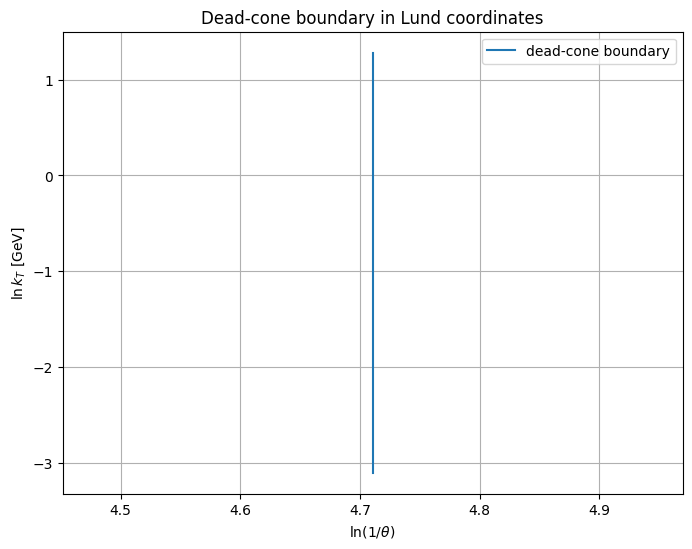

In [5]:
z_vals = np.geomspace(z_min, z_max, n_points)
kT_dc_vals = dead_cone_kT_boundary(z_vals, m_quark_GeV)
y_dc_vals = np.log(kT_dc_vals)

plt.figure(figsize=(8, 6))
plt.plot(np.full_like(y_dc_vals, x_dc), y_dc_vals, label='dead-cone boundary')
plt.xlabel(r'$\ln(1/\theta)$')
plt.ylabel(r'$\ln k_T\;[\mathrm{GeV}]$')
plt.title('Dead-cone boundary in Lund coordinates')
plt.legend()
plt.grid(True)
plt.show()


## Plot 2: Boundary in $(\ln(1/\theta), \ln(1/z))$

In this representation, the dead cone is again a vertical line.

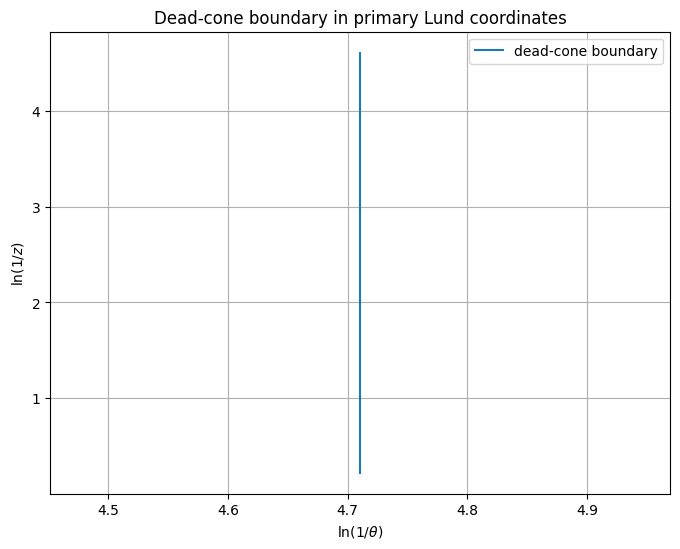

In [6]:
y2_vals = np.log(1.0 / z_vals)

plt.figure(figsize=(8, 6))
plt.plot(np.full_like(y2_vals, x_dc), y2_vals, label='dead-cone boundary')
plt.xlabel(r'$\ln(1/\theta)$')
plt.ylabel(r'$\ln(1/z)$')
plt.title('Dead-cone boundary in primary Lund coordinates')
plt.legend()
plt.grid(True)
plt.show()


## Plot 3: $k_T^{(dc)} \simeq z m_Q$

This makes the mass dependence of the boundary explicit.

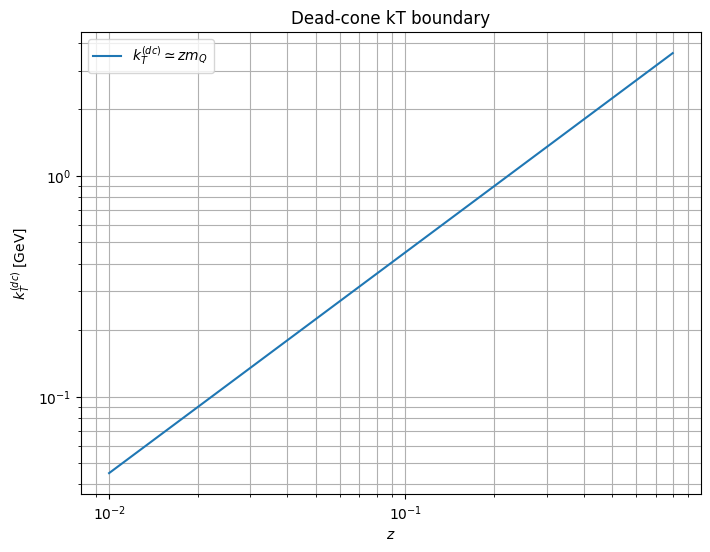

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(z_vals, kT_dc_vals, label=r'$k_T^{(dc)} \simeq z m_Q$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$k_T^{(dc)}\;[\mathrm{GeV}]$')
plt.title('Dead-cone kT boundary')
plt.legend()
plt.grid(True, which='both')
plt.show()


## Optional helper: compare several quark masses or energies

Edit the lists below to compare different scenarios on the same Lund plane.

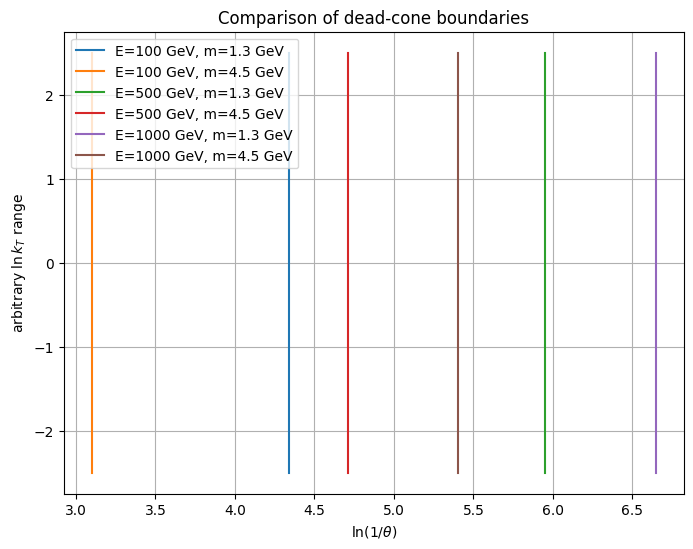

In [8]:
E_list = [100.0, 500.0, 1000.0]
m_list = [1.3, 4.5]

y_ref = np.linspace(-2.5, 2.5, 300)

plt.figure(figsize=(8, 6))
for E in E_list:
    for m in m_list:
        if m > 0 and E > m:
            x = dead_cone_boundary_x(E, m)
            plt.plot(np.full_like(y_ref, x), y_ref, label=f'E={E:g} GeV, m={m:g} GeV')

plt.xlabel(r'$\ln(1/\theta)$')
plt.ylabel(r'arbitrary $\ln k_T$ range')
plt.title('Comparison of dead-cone boundaries')
plt.legend()
plt.grid(True)
plt.show()
